# 04_cnn_conv_svd— Fashion-MNIST

## 1. import

実験で使うライブラリと `nn_compression` の関数を読み込む。学習ループ・SVD・指標計算は Notebook 内に再定義しない。


In [1]:
# 標準ライブラリ
from __future__ import annotations
import copy
import itertools

from copy import deepcopy
from pathlib import Path
import json
import platform
import random
import sys

# データ処理・可視化
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 評価
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.preprocessing import MinMaxScaler
# ============================================================
# 【.py側をimport】元の03ではここに def / class を書いていた
# ============================================================
# SVD圧縮: 元03では SVD / devidetwolayer（現 factorize_linear_layer）/
# make_two_layer_svd_model をセル定義
from nn_compression.compression import (
    factorize_linear_layer,
    factorize_named_linear,
    factorize_conv2d_layer,
    retained_energy,
    truncated_svd,
    make_two_layer_svd_model,
)

# データ準備: 元03では FashionMNIST / random_split / DataLoader を直書き
from nn_compression.datasets import (
    get_fashion_mnist_datasets,      # datasets/fashion_mnist.py
    make_fashion_mnist_loaders,      # 同上
    split_fashion_mnist_dataset,     # 同上
)

# 評価指標: 元03では各セルで def していた
from nn_compression.metrics import (
    accuracy_drop,           # metrics/model_comparison.py
    agreement,               # metrics/model_comparison.py
    benchmark_inference,     # metrics/model_comparison.py
    count_parameters,        # metrics/model_comparison.py
    logits_rmse,             # metrics/model_comparison.py
    parameters_reduction,    # metrics/model_comparison.py
    compressed_linear_macs,
    linear_macs,
    conv2d_macs,
    compressed_conv2d_macs,
    estimate_cnn_conv2_macs,
)

# モデル: 元03では class MNISTMLP(nn.Module): をNotebook内に書いていた
from nn_compression.models import FashionMNISTCNN  # models/cnn.py

# Pareto / knee: 元03では GetPoint などをセル定義していた
# .py化に合わせて、Python標準の snake_case 名へ整理している
from nn_compression.selection import (
    extract_pareto_frontier, # selection/pareto.py
    find_knee_point,         # selection/knee.py
    get_first_point,         # selection/knee.py
    line_equation,           # selection/knee.py
)

# 学習: 元03では train_one_epoch / evaluate / Early Stoppingループを直書き
from nn_compression.training import (
    evaluate,                 # training/loops.py
    train_one_epoch,          # training/loops.py
    fit_with_early_stopping,  # training/fit.py（Early Stopping付き学習）
)

# パス・seed: 元03では find_project_root / set_seed をNotebook内に定義
from nn_compression.utils import (
    find_project_root,     # utils/paths.py
    get_experiment_dirs,   # utils/paths.py
    make_torch_generator,  # utils/seed.py
    set_seed,              # utils/seed.py
)


## 2. 再現性と実行デバイス

seed を 0 に固定し、CUDA / MPS / CPU から使うデバイスを決める。


In [2]:
# 再現性のため seed を固定する。MLP実験と同じ 0 にして比較しやすくする。
SEED = 0
# 【.py】utils/seed.py。Python / NumPy / PyTorch の乱数源をまとめて固定する
set_seed(SEED)

# 使えるハードウェアを優先順に選ぶ: CUDA GPU → Apple MPS → CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"device: {device}")
print(f"PyTorch: {torch.__version__}")


device: cuda
PyTorch: 2.11.0+cu128


## 3. 保存先

`get_experiment_dirs` で data / models / results をプロジェクトルート基準に作る。02 を上書きしないよう、出力先は `03_cnn_linear_svd_finetuning`。


In [3]:
# MLP実験と同じく、プロジェクトルート基準で保存先を決める
# Path(".") だと Notebook の cwd 次第で data/results がズレる
DATASET_NAME = "20_fashion_mnist"
EXPERIMENT_NAME = "04_cnn_conv_svd"

project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    DATASET_NAME,
    EXPERIMENT_NAME,
)

# このNotebook内の既存変数名に合わせる
# 重み → models/..., CSV・図・metadata → results/...
checkpoint_dir = models_dir
csv_dir = results_dir
figure_dir = results_dir
metadata_dir = results_dir

print("project_root:", project_root)
print("data_dir:", data_dir)
print("models_dir:", models_dir)
print("results_dir:", results_dir)


project_root: D:\dev\nn-compression-svd-dmrg
data_dir: D:\dev\nn-compression-svd-dmrg\data
models_dir: D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\04_cnn_conv_svd
results_dir: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd


## 4. Fashion-MNISTの読み込み

`ToTensor()` で画像を `(1, 28, 28)` のテンソルにする。公式の学習 60,000 枚を train / validation に分け、test 10,000 枚は最終評価まで使わない。


In [4]:
# 画像をPyTorchで扱える torch.Tensor に変換するための変換処理オブジェクトを作っています。
# Datasetに渡すと、各画像を取り出すたびにこの変換が適用されます。
# ToTensor(): PIL Image (28×28) → Tensor (1, 28, 28)、値域は [0, 1]
transform = transforms.ToTensor()

# 【.py】get_experiment_dirs が返した data/ を使う（cwd に依存しない）
data_root = data_dir

# train=True: 公式の学習用 60,000 枚。後で train / validation に分割する
full_train_dataset = datasets.FashionMNIST(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)

# train=False: 公式のテスト 10,000 枚。最終評価まで使わない
test_dataset = datasets.FashionMNIST(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

train_size = 50_000
validation_size_early_stop = 5_000
validation_size_rank = 5_000

# random_split の分割結果を seed で固定する
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, validation_dataset_early_stop,validation_dataset_rank = random_split(
    full_train_dataset,
    lengths=[train_size, validation_size_early_stop,validation_size_rank],
    generator=split_generator,
)

print(f"train:      {len(train_dataset):,}")
print(f"validation_early_stop: {len(validation_dataset_early_stop):,}")
print(f"validation_rank: {len(validation_dataset_rank):,}")
print(f"test:       {len(test_dataset):,}")


train:      50,000
validation_early_stop: 5,000
validation_rank: 5,000
test:       10,000


## 5. DataLoader

batch size 256、`num_workers=0` で学習・Early Stopping 用 validation・rank 比較用 validation・test のローダを作る。`train_loader` を `next(iter(...))` すると shuffle 用 Generator を消費するので、shape 確認は `train_dataset[0]` で行う。


In [5]:
BATCH_SIZE = 256
# データを読む・画像変換する・バッチ化するための子プロセス数です。
#0：メインプロセス自身がデータを読み込む。デバッグしやすく、Windows/Jupyterで問題を切り分けやすい
#1 以上：複数の子プロセスが次のバッチを並列に準備するため、ディスクI/Oや画像拡張が重い場合に学習待ち時間を減らせる
#増やしすぎると、CPU競合・メモリ使用量増加・プロセス起動のオーバーヘッドで、かえって遅くなることがある
#num_workers はGPU数ではなく、CPU側のデータ準備担当者の人数です。
# まず 0 で正しく動作を確認し、2, 4, 8 などを実測して、1 epochあたりの時間が最短になる値を選ぶのが確実です。
NUM_WORKERS = 0

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    #num_workers は、DataLoaderがデータを読み込み・前処理・バッチ化するために使う子プロセスの数です。
    # 大きくすると、次のバッチを並列に準備できるため、GPUがデータ待ちになる時間を減らせる場合があります。
    num_workers=NUM_WORKERS,
    # CUDA GPUを使うときだけ True にする設定です。
    # True なら、DataLoaderが返すCPUテンソルをページロック（pinned）メモリに置き、
    # CPUからGPUへの転送を速くしやすくします。
    # CPU側の転送用メモリを固定する設定です。
    # 小さなデータやCPU学習では効果が乏しく、ホストメモリの負担もあるため、CUDA時だけ有効にする現在の書き方がよいです。
    pin_memory=(device.type == "cuda"),
    # shuffle=True で使うランダムなデータ順序を制御する torch.Generator です。
    # 通常は再現性のためにシード固定済みのジェネレータを渡します。
    generator=loader_generator,
)

validation_loader_early_stop = DataLoader(
    validation_dataset_early_stop,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

validation_loader_rank = DataLoader(
    validation_dataset_rank,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# train_loader を next(iter(...)) すると shuffle 用 Generator を消費するので避ける
image, label = train_dataset[0]
print(f"image shape: {tuple(image.shape)}")
print(f"label: {label}")
print(f"batch images shape: ({BATCH_SIZE}, {image.shape[0]}, {image.shape[1]}, {image.shape[2]})")


image shape: (1, 28, 28)
label: 6
batch images shape: (256, 1, 28, 28)


## 6. CNNモデルの定義

Conv2d → ReLU → MaxPool を2回したあと Flatten し、`Linear(3136, 128)` → `Linear(128, 10)` で分類する。次の SVD 対象は後段の `conv2`。


In [6]:
# FashionMNISTCNN は src/nn_compression/models/cnn.py から import 済み。
# 構造は Notebook 定義時と同じ:
# Conv(1→32) → Pool → Conv(32→64) → Pool → Linear(3136→128) → Linear(128, 10)


## 7. 総パラメータ数

CNN をデバイスへ載せ、学習可能な重みの総数を数える。この設計なら 421,642 になる。


In [7]:
baseline_model = FashionMNISTCNN().to(device)
# 【.py】metrics/model_comparison.py。学習可能・非学習可能を問わず全要素数を数える
baseline_parameter_count = count_parameters(
    baseline_model
)

print(f"parameters: {baseline_parameter_count:,}")

# モデルを上の設計通りに書けていれば421,642になる。
assert baseline_parameter_count == 421_642


parameters: 421,642


## 8. 層ごとのパラメータ数

`named_parameters()` で各層の shape と要素数を出し、`fc1` が大きいことを確認する。


In [8]:
# 各層のパラメータ数も確認する。
#named_parameters() は、
# PyTorchモデルの学習対象パラメータを
# 「名前」と「Tensor」の組で取り出すメソッドです。
# numel(): その Tensor の要素数 = その層のパラメータ数
for name, parameter in baseline_model.named_parameters():
    print(
        f"{name:20s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"params={parameter.numel():,}"
    )


conv1.weight         shape=(32, 1, 3, 3)      params=288
conv1.bias           shape=(32,)              params=32
conv2.weight         shape=(64, 32, 3, 3)     params=18,432
conv2.bias           shape=(64,)              params=64
fc1.weight           shape=(128, 3136)        params=401,408
fc1.bias             shape=(128,)             params=128
fc2.weight           shape=(10, 128)          params=1,280
fc2.bias             shape=(10,)              params=10


## 9. Baseline学習

多クラス分類なので `CrossEntropyLoss` と Adam を使い、Early Stopping 付きで Baseline CNN を学習する。


In [9]:
# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

BASELINE_LEARNING_RATE = 1e-3
BASELINE_EPOCHS = 30
PATIENCE=3
MIN_DELTA = 1e-4

# Adam: 学習率 0.001 はよく使う初期値
optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
)

baseline_fit = fit_with_early_stopping(
    baseline_model,
    train_loader,
    validation_loader_early_stop,
    criterion,
    optimizer,
    device,
    BASELINE_EPOCHS,
    PATIENCE,
    MIN_DELTA,
)

Early stopping at epoch 18


## 10. 学習履歴の保存

最良 epoch と validation loss を確認し、`fit_history.csv` と `fit_loss_history.csv` に書き出す。


In [10]:
# fit_with_early_stopping の学習履歴。CSV保存とグラフ用に取り出す
history = baseline_fit["history"]
train_loss_history = baseline_fit["train_loss_history"]
validation_loss_history = baseline_fit["validation_loss_history"]
best_epoch = baseline_fit["best_epoch"]
best_validation_loss = baseline_fit["best_validation_loss"]
df_training_history = pd.DataFrame(history)

print()
print(f"best epoch: {best_epoch}")
print(
    "best validation loss: "
    f"{best_validation_loss:.4f}"
)
print(f"epochs recorded: {len(history)}")

# epochごとの詳細履歴（loss / acc）
history_csv = csv_dir / "fit_history.csv"
df_training_history.to_csv(history_csv, index=False)

# 戻り値の1次元リストも保存しておく
loss_history_csv = csv_dir / "fit_loss_history.csv"
pd.DataFrame(
    {
        "epoch": list(range(1, len(train_loss_history) + 1)),
        "train_loss": train_loss_history,
        "validation_loss": validation_loss_history,
    }
).to_csv(loss_history_csv, index=False)

print("saved:", history_csv)
print("saved:", loss_history_csv)



best epoch: 15
best validation loss: 0.2118
epochs recorded: 18
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\fit_history.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\fit_loss_history.csv


## 11. 学習曲線

履歴を表で表示し、loss / accuracy の epoch 推移を描く。最良重みの `state_dict` も控えておく。


Best epoch: 15
Best validation loss: 0.2118


,epoch,train_acc,train_loss,validation_loss,validation_acc
0,1,0.84964,0.418617,0.428412,0.8436
1,2,0.87994,0.336759,0.346146,0.8728
2,3,0.89324,0.297944,0.311885,0.8818
3,4,0.90096,0.274460,0.284831,0.8924
4,5,0.91546,0.236532,0.262072,0.9028
5,6,0.91900,0.226321,0.253714,0.9046
6,7,0.92140,0.216312,0.247131,0.9106
7,8,0.93026,0.193128,0.238698,0.9094
8,9,0.93386,0.183458,0.231532,0.9124
9,10,0.93854,0.171534,0.236342,0.9134


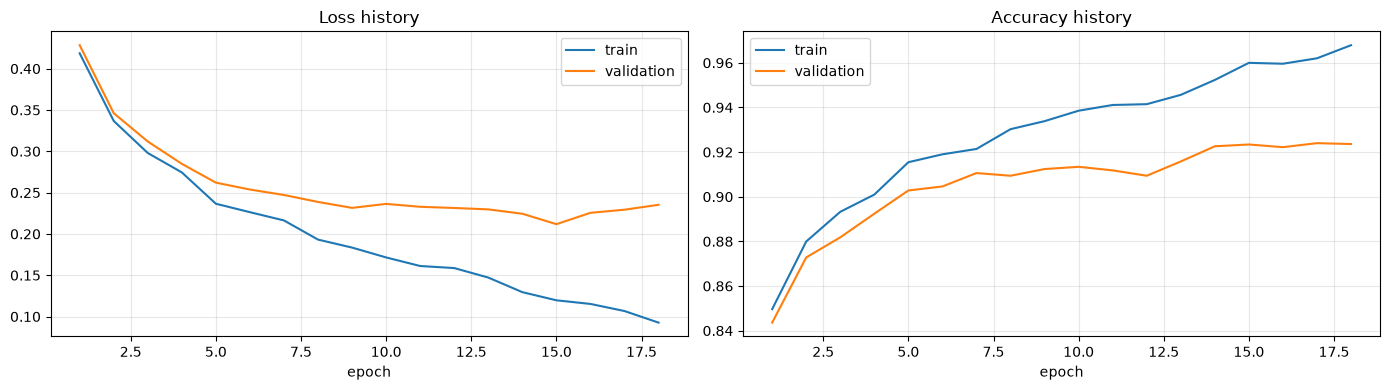

In [11]:
from IPython.display import display

model = baseline_fit["model"]
baseline_state = copy.deepcopy(model.state_dict())

# 【.ipynb側】履歴を DataFrame / グラフにするのは実験ノートの仕事
df_training_history = pd.DataFrame(baseline_fit["history"])

print("Best epoch:", baseline_fit["best_epoch"])
print(f"Best validation loss: {baseline_fit['best_validation_loss']:.4f}")
display(df_training_history)

fig_learning, axes_learning = plt.subplots(1, 2, figsize=(14, 4))
axes_learning[0].plot(df_training_history["epoch"], df_training_history["train_loss"], label="train")
axes_learning[0].plot(df_training_history["epoch"], df_training_history["validation_loss"], label="validation")
axes_learning[0].set_title("Loss history")
axes_learning[0].set_xlabel("epoch")
axes_learning[0].legend()
axes_learning[0].grid(True, alpha=0.3)

axes_learning[1].plot(df_training_history["epoch"], df_training_history["train_acc"], label="train")
axes_learning[1].plot(df_training_history["epoch"], df_training_history["validation_acc"], label="validation")
axes_learning[1].set_title("Accuracy history")
axes_learning[1].set_xlabel("epoch")
axes_learning[1].legend()
axes_learning[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. MACsの見積もり

`conv2` を `kH×kW Conv(in → rank)` + `1×1 Conv(rank → out)` に分解したときの MACs と削減率を、元の Conv2d と比較して出す。この CNN では pool1 後が 14×14 で、`conv2` の出力も 14×14 になる。


In [12]:
# この処理は src/nn_compression から import 済み。


In [13]:
# この処理は src/nn_compression から import 済み。


## 14. SVD rank sweep

`conv` の rank 候補を走査し、圧縮直後（未学習）の validation loss / acc、パラメータ削減、agreement などを表にまとめる。


In [14]:
R1_LIST = [16,20,24,28,32,36,42,44,48,64]  # conv2 の rank 候補


# 【.py】metrics/model_comparison.py / metrics/mlp_macs.py
baseline_time_s = benchmark_inference(
    model,
    validation_loader_rank,
    device,
    warmup=20,    # 【.ipynb】ベンチ条件
    repeats=2000, # 【.ipynb】ベンチ条件
)
# 【.py】training/loops.py
baseline_rank_validation_loss, baseline_rank_validation_acc = evaluate(
    model,
    validation_loader_rank,
    criterion,
    device,
)

rank_results = []

for conv2_rank in R1_LIST:

    # 予め、SVD用に切り出しておく
    compressed_model = copy.deepcopy(model)

    New_Conv2 = factorize_conv2d_layer(
        model.conv2,
        conv2_rank,
    )

    compressed_model.conv2=New_Conv2


    validation_loss, validation_acc = evaluate(
        compressed_model,
        validation_loader_rank,
        criterion,
        device,
    )
    # 【.py】metrics/*
    drop = accuracy_drop(
        baseline_rank_validation_acc,
        validation_acc,
        verbose=False,
    )
    # 【.py】metrics/mlp_macs.py
    _, compressed_macs, compute_reduction = estimate_cnn_conv2_macs(
        model,
        conv2_rank,
        verbose=False,
    )
    compressed_time_s = benchmark_inference(
        compressed_model,
        validation_loader_rank,
        device,
        warmup=5,
        repeats=200,
    )

    # 【.ipynb側】どの列を結果表に入れるかは実験設計
    row = {
        "conv2_rank": conv2_rank,
        "parameters": count_parameters(compressed_model),
        "parameters_reduction": parameters_reduction(model, compressed_model),
        "validation_loss": validation_loss,
        "validation_acc": validation_acc,
        "accuracy_drop": drop,
        "compressed_macs": compressed_macs,
        "compute_reduction": compute_reduction,
        "baseline_time_ms": baseline_time_s * 1000,
        "compressed_time_ms": compressed_time_s * 1000,
        "agreement": agreement(model, compressed_model, validation_loader_rank, device),
        "logits_rmse": logits_rmse(model, compressed_model, validation_loader_rank, device),
        "retained_energy_conv2": retained_energy(model.conv2, conv2_rank),
        "model": compressed_model,
    }
    rank_results.append(row)
    print(
        f"r1={conv2_rank:3d}| "
        f"Acc={validation_acc:.4f} loss={validation_loss:.4f} | "
        f"params={row['parameters']} MACs={compressed_macs} | "
        f"agreement={row['agreement']:.4f}"
    )

print(f"\n集計完了: {len(rank_results)} 件")


r1= 16| Acc=0.8986 loss=0.2880 | params=408842 MACs=1103872 | agreement=0.9462
r1= 20| Acc=0.9090 loss=0.2618 | params=410250 MACs=1379840 | agreement=0.9604
r1= 24| Acc=0.9102 loss=0.2498 | params=411658 MACs=1655808 | agreement=0.9680
r1= 28| Acc=0.9216 loss=0.2303 | params=413066 MACs=1931776 | agreement=0.9796
r1= 32| Acc=0.9206 loss=0.2270 | params=414474 MACs=2207744 | agreement=0.9836
r1= 36| Acc=0.9234 loss=0.2216 | params=415882 MACs=2483712 | agreement=0.9868
r1= 42| Acc=0.9234 loss=0.2185 | params=417994 MACs=2897664 | agreement=0.9904
r1= 44| Acc=0.9234 loss=0.2184 | params=418698 MACs=3035648 | agreement=0.9912
r1= 48| Acc=0.9254 loss=0.2171 | params=420106 MACs=3311616 | agreement=0.9926
r1= 64| Acc=0.9254 loss=0.2156 | params=425738 MACs=4415488 | agreement=1.0000

集計完了: 10 件


## 15. Pareto frontier

パラメータ数が baseline 以下で、かつ計算量が減っている点だけを残し、validation loss との非劣後点を正規化して散布図にする。`model` 列は CSV に書かない。


pareto points: 9


,conv2_rank,parameters,validation_loss,parameters_normalize,validation_loss_normalize
0,16,408842,0.287995,0.0000,1.000000
1,20,410250,0.261762,0.1250,0.630083
2,24,411658,0.249816,0.2500,0.461634
3,28,413066,0.230316,0.3750,0.186661
4,32,414474,0.227031,0.5000,0.140338
5,36,415882,0.221559,0.6250,0.063172
6,42,417994,0.218495,0.8125,0.019978
7,44,418698,0.218446,0.8750,0.019287
8,48,420106,0.217079,1.0000,0.000000


saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\rank_sweep_results.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\pareto_frontier.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\parameters_vs_validation_loss_normalize.png


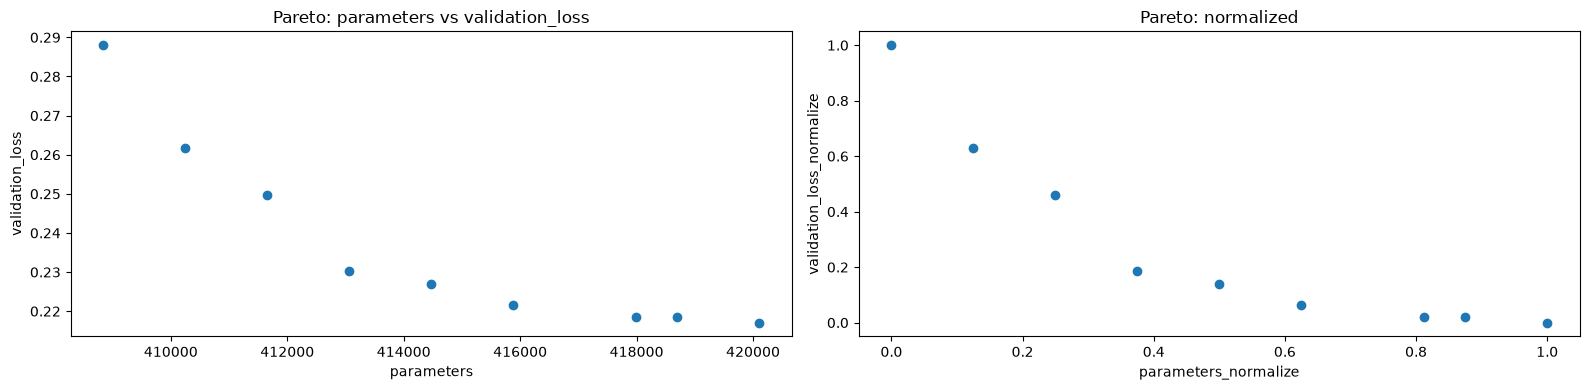

In [15]:
# ============================================================
# 【.ipynb側】前処理フィルタ・正規化・プロット
# 【.py側】Pareto frontier抽出だけ extract_pareto_frontier に任せる
# 元03では dominated判定の for ループをNotebook内に書いていた
# ============================================================
baseline_params = count_parameters(model)  # 【.py】metrics/model_comparison.py
df_rank_results = pd.DataFrame(rank_results)

# 【.ipynb側】「baselineより大きいparamsを落とす」等は実験判断
df_pareto_input = df_rank_results[
    (df_rank_results["parameters"] <= baseline_params)
    & (df_rank_results["compute_reduction"] > 0)
].copy()

# 【.py】selection/pareto.py
# 両目的とも小さいほど良い場合の非劣後点を返す
df_pareto_view = extract_pareto_frontier(
    df_pareto_input,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】どの列を正規化するかは実験設計
scaler = MinMaxScaler()
df_pareto_view[
    ["parameters_normalize", "validation_loss_normalize"]
] = scaler.fit_transform(
    df_pareto_view[["parameters", "validation_loss"]]
)

# 【.ipynb側】可視化
fig_pareto, axes_pareto = plt.subplots(1, 2, figsize=(16, 4))
axes_pareto[0].scatter(
    df_pareto_view["parameters"],
    df_pareto_view["validation_loss"],
)
axes_pareto[0].set_xlabel("parameters")
axes_pareto[0].set_ylabel("validation_loss")
axes_pareto[0].set_title("Pareto: parameters vs validation_loss")

axes_pareto[1].scatter(
    df_pareto_view["parameters_normalize"],
    df_pareto_view["validation_loss_normalize"],
)
axes_pareto[1].set_xlabel("parameters_normalize")
axes_pareto[1].set_ylabel("validation_loss_normalize")
axes_pareto[1].set_title("Pareto: normalized")
plt.tight_layout()

print("pareto points:", len(df_pareto_view))
display(
    df_pareto_view[
        [
            "conv2_rank",
            "parameters",
            "validation_loss",
            "parameters_normalize",
            "validation_loss_normalize",
        ]
    ]
)

# 【.py】results_dir は get_experiment_dirs（utils/paths.py）
# 【.ipynb側】ファイル名と「model列はCSVに書かない」は実験判断
# MLP 02 と同じ成果物名で、このセルの結果を保存する
results_dir.mkdir(parents=True, exist_ok=True)
rank_sweep_path = results_dir / "rank_sweep_results.csv"
pareto_path = results_dir / "pareto_frontier.csv"
pareto_figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"

df_rank_results.drop(columns=["model"], errors="ignore").to_csv(
    rank_sweep_path,
    index=False,
)
df_pareto_view.drop(columns=["model"], errors="ignore").to_csv(
    pareto_path,
    index=False,
)
fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")

print("saved:", rank_sweep_path)
print("saved:", pareto_path)
print("saved:", pareto_figure_path)
plt.show()


## 16. knee ±1

正規化 Pareto の端点を結ぶ直線から最も遠い点を knee とし、その前後1点も次の候補にする。


In [16]:
# ============================================================
# 【.py】get_first_point / line_equation / find_knee_point
# 元03の GetPoint / GetlinearEquation / GetKneePoint_loop を
# Python標準の snake_case 名へ整理して移植
# 【.ipynb側】knee±1を候補にする、という実験判断はここに残す
# ============================================================

# 【.py】selection/knee.py
# get_first_point: 指定列でソートした先頭点の座標を返す
p0 = get_first_point(
    df_pareto_view,
    "parameters_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)
p1 = get_first_point(
    df_pareto_view,
    "validation_loss_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)

# 端点を結ぶ直線から最も遠い点が knee
knee_point, knee_distance = find_knee_point(
    df_pareto_view,
    *line_equation(p0, p1),
    "parameters_normalize",
    "validation_loss_normalize",
)

# 【.ipynb側】kneeの前後1点もFine-tuning候補にする
df_pareto_view = df_pareto_view.sort_values("parameters").reset_index(drop=True)
knee_mask = (
    (df_pareto_view["parameters_normalize"] == knee_point[0])
    & (df_pareto_view["validation_loss_normalize"] == knee_point[1])
)
knee_pos = int(df_pareto_view.index[knee_mask][0])
left = max(knee_pos - 1, 0)
right = min(knee_pos + 1, len(df_pareto_view) - 1)

df_pareto_knee = df_pareto_view.iloc[[knee_pos]].copy()
df_pareto_best = df_pareto_view.iloc[left : right + 1].copy()

print("knee distance:", knee_distance)
print(f"knee_pos={knee_pos}, neighbors iloc[{left}:{right + 1}]")
print("knee:")
display(df_pareto_knee.drop(columns="model"))
print("knee ±1:")
display(df_pareto_best.drop(columns="model"))

knee distance: 0.30995254512428133
knee_pos=3, neighbors iloc[2:5]
knee:


,conv2_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_conv2,parameters_normalize,validation_loss_normalize
3,28,413066,0.02034,0.230316,0.9216,0.0038,1931776,0.465278,0.386357,0.396146,0.9796,0.578214,0.863418,0.375,0.186661


knee ±1:


,conv2_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_conv2,parameters_normalize,validation_loss_normalize
2,24,411658,0.023679,0.249816,0.9102,0.0152,1655808,0.541667,0.386357,0.417057,0.9680,0.776895,0.825743,0.250,0.461634
3,28,413066,0.020340,0.230316,0.9216,0.0038,1931776,0.465278,0.386357,0.396146,0.9796,0.578214,0.863418,0.375,0.186661
4,32,414474,0.017000,0.227031,0.9206,0.0048,2207744,0.388889,0.386357,0.381709,0.9836,0.418914,0.892792,0.500,0.140338


## 17. Fine-tuning（knee ±1）

SVD 圧縮した候補ごとに optimizer と seed を作り直し、Early Stopping で Fine-tuning する。構造が変わっているので optimizer は使い回さない。


In [17]:
# ============================================================
# 【.ipynb側】どの候補をFine-tuningするか、候補ごとの seed / optimizer
# 【.py側】学習ループ本体は fit_with_early_stopping を再利用
# 元03では for re_epoch in range(MAX_EPOCHS): を直書きしていた
# ============================================================
set_seed(SEED)
fine_tuned_records = []
LEARNING_RATE=3e-4
MAX_EPOCHS = 30

# iterrowsは1行ごとに行のインデックスと列のインデックスを返す
for _, pareto_row in df_pareto_best.iterrows():
    conv2_rank = int(pareto_row["conv2_rank"])
    fine_tuned_model = copy.deepcopy(pareto_row["model"]).to(device)

    # 【.ipynb側】候補ごとに optimizer を作り直す（元03と同じ注意点）
    # SVDする前は1層を2層Conv2dにしてなくて、SVD後はするから、
    # 構造が違うから、optimzerを作り直す
    candidate_optimizer = torch.optim.Adam(
        fine_tuned_model.parameters(),
        lr=LEARNING_RATE,
    )
    # 各候補を同じ乱数条件・同じshuffle順で比較する
    set_seed(SEED)
    loader_generator.manual_seed(SEED)
    print(f"\n=== fine-tune r1={conv2_rank} ===")

    # 【.py】training/fit.py を baseline 学習と同じく再利用
    fit_result = fit_with_early_stopping(
        model=fine_tuned_model,
        train_loader=train_loader,
        val_loader=validation_loader_early_stop,  # Early Stopping用（rank用ではない）
        criterion=criterion,
        optimizer=candidate_optimizer,
        device=device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
    )

    fine_tuned_records.append(
        {
            "conv2_rank": conv2_rank,
            "best_epoch": fit_result["best_epoch"],
            "best_validation_loss": fit_result["best_validation_loss"],
            "history": fit_result["history"],
            "model": fit_result["model"],
        }
    )

df_fine_tuned_models = pd.DataFrame(fine_tuned_records)
display(df_fine_tuned_models.drop(columns=["history", "model"]))


=== fine-tune r1=24 ===
Early stopping at epoch 5

=== fine-tune r1=28 ===
Early stopping at epoch 5

=== fine-tune r1=32 ===
Early stopping at epoch 5


,conv2_rank,best_epoch,best_validation_loss
0,24,2,0.221516
1,28,2,0.218864
2,32,2,0.218634


## 18. Fine-tuning前後の比較

候補を Aggressive / Balanced / Conservative と名付け、validation 上の acc / loss の変化を表とグラフにする。



=== fine-tune r1=24 ===

=== fine-tune r1=28 ===

=== fine-tune r1=32 ===


,candidate,conv2_rank,acc_before,acc_after,delta_acc,loss_before,loss_after,delta_loss
0,Aggressive,24,0.9102,0.925,0.0148,0.249816,0.210216,-0.039600
1,Balanced,28,0.9216,0.926,0.0044,0.230316,0.209334,-0.020982
2,Conservative,32,0.9206,0.924,0.0034,0.227031,0.209582,-0.017449


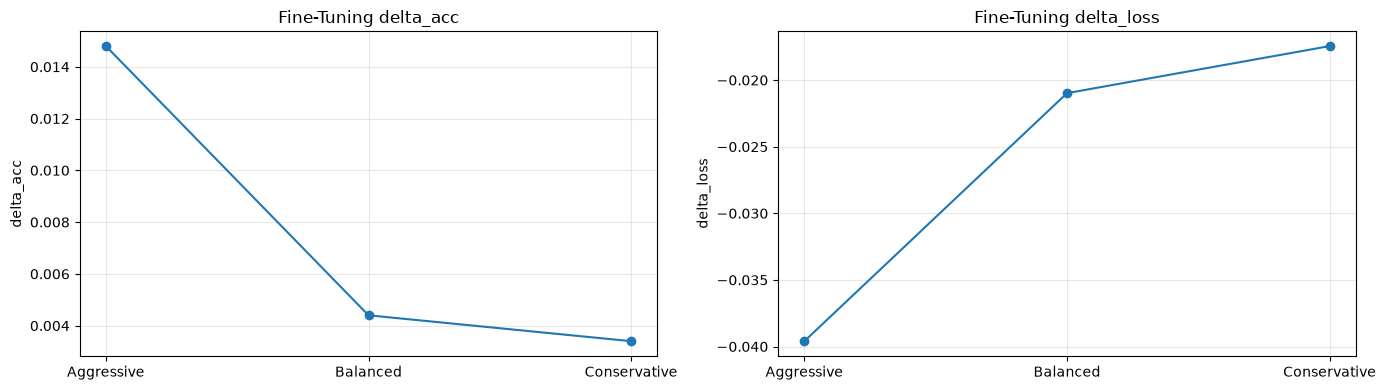

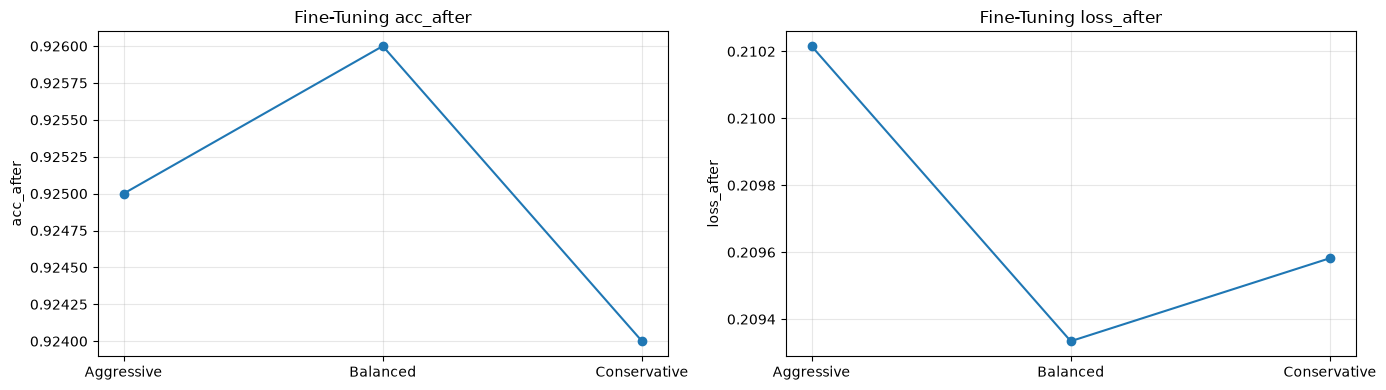

In [18]:
# ============================================================
# 【.ipynb側】候補名付け・比較表・グラフ（実験固有）
# 【.py側】evaluate だけ再利用
# ============================================================
fine_tuning_records = []

for idx, pareto_row in df_pareto_best.iterrows():
    conv2_rank = int(pareto_row["conv2_rank"])

    # 【.ipynb側】kneeより左/本体/右のラベル（元03と同じ）
    if idx < knee_pos:
        candidate = "Aggressive"
    elif idx == knee_pos:
        candidate = "Balanced"
    else:
        candidate = "Conservative"

    matched = df_fine_tuned_models[
        (df_fine_tuned_models["conv2_rank"] == conv2_rank)
    ]
    if len(matched) != 1:
        raise ValueError(
            f"Fine-tuning済みモデルが一意に見つかりません: "
            f"r1={conv2_rank} matches={len(matched)}"
        )
    print(f"\n=== fine-tune r1={conv2_rank} ===")
    # 【.py】evaluate。比較は Early Stopping用ではなく validation_loader_rank
    loss_after, acc_after = evaluate(
        matched.iloc[0]["model"],
        validation_loader_rank,
        criterion,
        device,
    )
    acc_before = float(pareto_row["validation_acc"])
    loss_before = float(pareto_row["validation_loss"])

    fine_tuning_records.append(
        {
            "candidate": candidate,
            "conv2_rank": conv2_rank,
            "acc_before": acc_before,
            "acc_after": acc_after,
            "delta_acc": acc_after - acc_before,
            "loss_before": loss_before,
            "loss_after": loss_after,
            "delta_loss": loss_after - loss_before,
        }
    )

df_fine_tuning_result = pd.DataFrame(fine_tuning_records)
display(df_fine_tuning_result)

# 【.ipynb側】可視化
fig_delta, axes_delta = plt.subplots(1, 2, figsize=(14, 4))
axes_delta[0].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["delta_acc"], marker="o")
axes_delta[0].set_title("Fine-Tuning delta_acc")
axes_delta[0].set_ylabel("delta_acc")
axes_delta[0].grid(True, alpha=0.3)
axes_delta[1].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["delta_loss"], marker="o")
axes_delta[1].set_title("Fine-Tuning delta_loss")
axes_delta[1].set_ylabel("delta_loss")
axes_delta[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig_after, axes_after = plt.subplots(1, 2, figsize=(14, 4))
axes_after[0].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["acc_after"], marker="o")
axes_after[0].set_title("Fine-Tuning acc_after")
axes_after[0].set_ylabel("acc_after")
axes_after[0].grid(True, alpha=0.3)
axes_after[1].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["loss_after"], marker="o")
axes_after[1].set_title("Fine-Tuning loss_after")
axes_after[1].set_ylabel("loss_after")
axes_after[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 19. 最終モデル選択と Test 評価

Fine-tuning 後の Pareto から最終1モデルを選び、ここで初めて test を Baseline と比較する。


In [19]:
# ============================================================
# 【.ipynb側】比較表の組み立て・最終選択ルール
# 【.py側】extract_pareto_frontier / evaluate / count_parameters を再利用
# ============================================================
df_candidate_params = df_pareto_best[
    ["conv2_rank", "parameters", "parameters_reduction"]
].copy()
df_after_comparison = df_fine_tuning_result.merge(
    df_candidate_params,
    on=["conv2_rank"],
    how="left",
    validate="one_to_one",
)

comparison_records = [
    {
        "model": "Baseline",
        "conv2_rank": "-",
        "validation_acc": baseline_rank_validation_acc,
        "validation_loss": baseline_rank_validation_loss,
        "parameters": baseline_params,
        "parameters_reduction": 0.0,
    }
]
for _, row in df_after_comparison.iterrows():
    comparison_records.append(
        {
            "model": f"{row['candidate']} after FT",
            "conv2_rank": int(row["conv2_rank"]),
            "validation_acc": row["acc_after"],
            "validation_loss": row["loss_after"],
            "parameters": int(row["parameters"]),
            "parameters_reduction": row["parameters_reduction"],
        }
    )

df_model_comparison = pd.DataFrame(comparison_records)
display(df_model_comparison)

# Baselineは圧縮モデルの選択対象から除外
df_final_candidates = df_model_comparison[
    df_model_comparison["model"] != "Baseline"
].copy()

# 【.py】selection/pareto.py を再度利用
df_final_pareto = extract_pareto_frontier(
    df_final_candidates,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】最終1モデルの優先順位（元03と同じ）
df_final_pareto = df_final_pareto.sort_values(
    by=["validation_loss", "parameters", "validation_acc"],
    ascending=[True, True, False],
).reset_index(drop=True)

final_model_result = df_final_pareto.iloc[0]
final_conv2_rank = int(final_model_result["conv2_rank"])
final_model = df_fine_tuned_models.loc[
    (df_fine_tuned_models["conv2_rank"] == final_conv2_rank),
    "model",
].iloc[0]

print("Selected final model:")
display(df_final_pareto.iloc[[0]])
print(f"Final model: r1={final_conv2_rank}")

# 最終選択後にTestを評価
final_test_loss, final_test_acc = evaluate(
    final_model,
    test_loader,
    criterion,
    device,
)
baseline_model_for_test = FashionMNISTCNN().to(device)
baseline_model_for_test.load_state_dict(baseline_state)
baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model_for_test,
    test_loader,
    criterion,
    device,
)

df_test_comparison = pd.DataFrame(
    [
        {
            "model": "Baseline",
            "conv2_rank": "-",
            "parameters": baseline_params,
            "test_loss": baseline_test_loss,
            "test_acc": baseline_test_acc,
            "delta_test_acc": 0.0,
            "delta_test_loss": 0.0,
        },
        {
            "model": "Final (compressed + FT)",
            "conv2_rank": final_conv2_rank,
            "parameters": count_parameters(final_model),
            "test_loss": final_test_loss,
            "test_acc": final_test_acc,
            "delta_test_acc": final_test_acc - baseline_test_acc,
            "delta_test_loss": final_test_loss - baseline_test_loss,
        },
    ]
)
display(df_test_comparison)

,model,conv2_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Baseline,-,0.9254,0.215624,421642,0.000000
1,Aggressive after FT,24,0.9250,0.210216,411658,0.023679
2,Balanced after FT,28,0.9260,0.209334,413066,0.020340
3,Conservative after FT,32,0.9240,0.209582,414474,0.017000


Selected final model:


,model,conv2_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Balanced after FT,28,0.926,0.209334,413066,0.02034


Final model: r1=28


,model,conv2_rank,parameters,test_loss,test_acc,delta_test_acc,delta_test_loss
0,Baseline,-,421642,0.234131,0.9175,0.0000,0.000000
1,Final (compressed + FT),28,413066,0.236488,0.9197,0.0022,0.002358


## 20. 結果の保存

Fine-tuning 結果、Test 比較、最終モデルの重みを `03_cnn_linear_svd_finetuning` へ保存する。CSV の `model` 列が PyTorch オブジェクトのときは落とす。


In [20]:
# ============================================================
# 【.ipynb側】何をどのファイル名で残すか（実験固有）
# 【.py側】results_dir / models_dir は get_experiment_dirs が用意済み
# ------------------------------------------------------------
# PyTorch の model オブジェクトは CSV に書かない。
# model_comparison / test_comparison の model 列は名前の文字列なので残す。
# ============================================================
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)


def _drop_model_col(df):
    """CSV 向けに model 列を除いたコピーを返す"""
    return df.drop(columns=["model"], errors="ignore")


selected_path = results_dir / "selected_rank.csv"
neighbors_path = results_dir / "selected_rank_neighbors.csv"
fine_tuning_csv = results_dir / "fine_tuning_result.csv"
test_comparison_csv = results_dir / "test_comparison.csv"
model_comparison_csv = results_dir / "model_comparison.csv"
selected_final_csv = results_dir / "selected_final_model.csv"

_drop_model_col(df_rank_results).to_csv(
    results_dir / "rank_sweep_results.csv",
    index=False,
)
_drop_model_col(df_pareto_view).to_csv(
    results_dir / "pareto_frontier.csv",
    index=False,
)
_drop_model_col(df_pareto_knee).to_csv(selected_path, index=False)
_drop_model_col(df_pareto_best).to_csv(neighbors_path, index=False)

df_fine_tuning_result.to_csv(fine_tuning_csv, index=False)
df_test_comparison.to_csv(test_comparison_csv, index=False)
df_model_comparison.to_csv(model_comparison_csv, index=False)
pd.DataFrame([final_model_result]).to_csv(selected_final_csv, index=False)

pareto_figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"
delta_figure_path = results_dir / "fine_tuning_delta.png"
after_figure_path = results_dir / "fine_tuning_after.png"
fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")
fig_delta.savefig(delta_figure_path, dpi=150, bbox_inches="tight")
fig_after.savefig(after_figure_path, dpi=150, bbox_inches="tight")

# CNN は fc1 のみなので、ファイル名に r2 は含めない
saved_model_paths = []
for _, row in df_fine_tuned_models.iterrows():
    r1 = int(row["conv2_rank"])
    matched = df_fine_tuning_result[df_fine_tuning_result["conv2_rank"] == r1]
    tag = str(matched.iloc[0]["candidate"]).lower()
    model_path = models_dir / f"r1-{r1}_{tag}_finetuned.pt"
    torch.save(row["model"].state_dict(), model_path)
    saved_model_paths.append(model_path)

final_model_path = models_dir / f"r1-{final_conv2_rank}_final.pt"
torch.save(final_model.state_dict(), final_model_path)

for path in [
    selected_path,
    neighbors_path,
    fine_tuning_csv,
    test_comparison_csv,
    model_comparison_csv,
    selected_final_csv,
    pareto_figure_path,
    delta_figure_path,
    after_figure_path,
    *saved_model_paths,
    final_model_path,
]:
    print("saved:", path)


saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\selected_rank.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\selected_rank_neighbors.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\fine_tuning_result.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\test_comparison.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\model_comparison.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\selected_final_model.csv
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\parameters_vs_validation_loss_normalize.png
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\fine_tuning_delta.png
saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd\fine_tuning_after.png
saved: D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\04_c

## 21. 保存先の確認

`results_dir` と `models_dir` を表示し、保存先が 03 用になっていることを確認する。


In [21]:
# Fine-tuning / Test / 最終モデルの保存は直前のセル
print("results_dir:", results_dir)
print("models_dir:", models_dir)


results_dir: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\04_cnn_conv_svd
models_dir: D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\04_cnn_conv_svd
